Name:Rushi Rvairaj Gujarathi ||Roll no-17 ||PRN NO-1252090017

Assingment no:13


Implement K-Means clustering on Iris.csv dataset. Determine the number of clusters using the elbow method. Dataset Link: https://www.kaggle.com/datasets/uciml/iris


In [ ]:
from numpy.random.mtrand import RandomState
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score


# Load Dataset
data = pd.read_csv("/content/Iris.csv")

# Data Cleaning
data = data.dropna()
print(data.isnull().sum())

data = data.drop_duplicates()
print(data.head())

# Drop Id column
data = data.drop("Id", axis=1)

# Select Features (all except species)
x = data.iloc[:, :-1].values

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

# Train Test Split
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

print("\n\n")



Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa





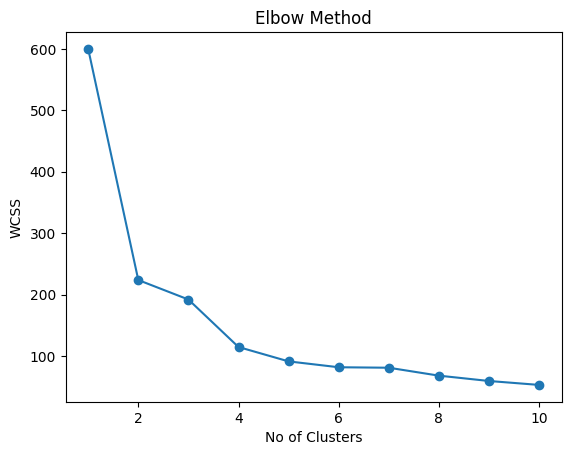

In [ ]:

# Elbow Method
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("No of Clusters")
plt.ylabel("WCSS")
plt.show()
print("\n\n")
print("\n\n")


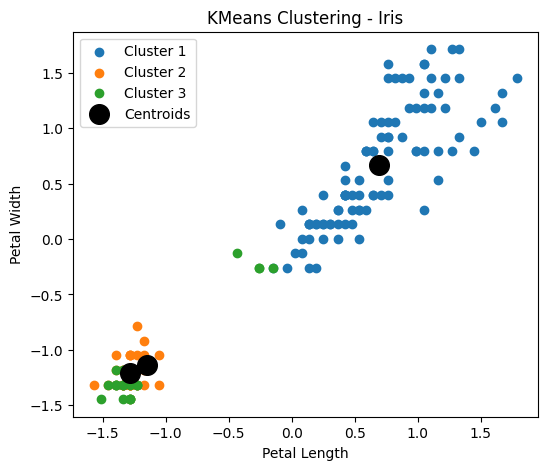


Silhouette Score KMeans: 0.4787241921049546








In [ ]:

# KMeans Clustering
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Scatter Plot (petal length vs width)
plt.figure(figsize=(6,5))
plt.scatter(X_scaled[y_kmeans==0,2], X_scaled[y_kmeans==0,3], label="Cluster 1")
plt.scatter(X_scaled[y_kmeans==1,2], X_scaled[y_kmeans==1,3], label="Cluster 2")
plt.scatter(X_scaled[y_kmeans==2,2], X_scaled[y_kmeans==2,3], label="Cluster 3")

plt.scatter(kmeans.cluster_centers_[:,2],kmeans.cluster_centers_[:,3],s=200, c='black', label="Centroids")

plt.title("KMeans Clustering - Iris")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.show()

# Silhouette Score (KMeans)
score = silhouette_score(X_scaled,y_kmeans)
print("\nSilhouette Score KMeans:", score )

print("\n\n")
print("\n\n")



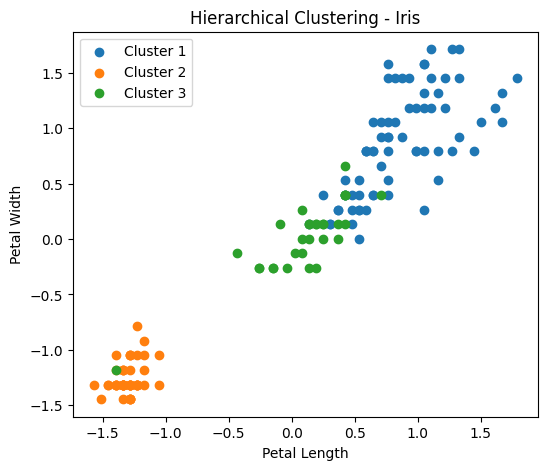


Silhouette Score Hierarchical: 0.44553956399200406








In [ ]:
# Hierarchical Clustering
hc = AgglomerativeClustering(n_clusters=3)
y_hc = hc.fit_predict(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_scaled[y_hc==0,2], X_scaled[y_hc==0,3], label="Cluster 1")
plt.scatter(X_scaled[y_hc==1,2], X_scaled[y_hc==1,3], label="Cluster 2")
plt.scatter(X_scaled[y_hc==2,2], X_scaled[y_hc==2,3], label="Cluster 3")

plt.title("Hierarchical Clustering - Iris")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.show()


# Silhouette Score (Hierarchical)
score_hc = silhouette_score(X_scaled, y_hc)
print("\nSilhouette Score Hierarchical:", score_hc)

print("\n\n")
print("\n\n")


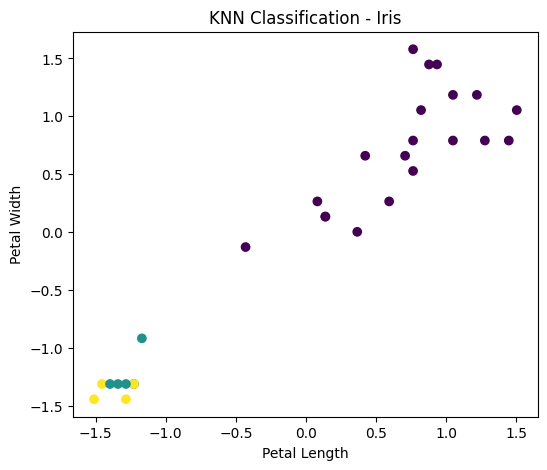


KNN Accuracy: 0.9666666666666667








In [ ]:
# KNN Classification
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_kmeans, test_size=0.2)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
accuracy = knn.score(X_test, y_test)

# KNN Scatter Plot
plt.figure(figsize=(6,5))
plt.scatter(X_test[:,2], X_test[:,3], c=knn.predict(X_test))
plt.title("KNN Classification - Iris")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()
print("\nKNN Accuracy:", accuracy)
